In [1]:
import uproot
import os
import dask_awkward as dak
import awkward as ak
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.ticker import PercentFormatter, FormatStrFormatter
import mplhep as hep
from dask.diagnostics import ProgressBar
import xgboost as xgb
import optuna
import cupy as cp
from optuna.samplers import TPESampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
import joblib

import uproot
import awkward as ak
import dask_awkward as dak
import pandas as pd
import numpy as np
import os
import joblib
import json
import warnings
from dask.diagnostics import ProgressBar

import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import (train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold, learning_curve)
from sklearn.metrics import (roc_curve, auc, precision_recall_curve, average_precision_score, 
                             confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score)

import zfit
from zfit.loss import UnbinnedNLL
from zfit.minimize import Minuit
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mplhep as hep

/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/zfit/__init__.py:93: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(


In [2]:
plt.style.use(hep.style.CMS)

In [3]:
tree_path = "Events"
data_files = {f: tree_path for f in [
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022C.root",
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022D.root",
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022E.root",
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022F.root",
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022G.root"
]}

In [4]:
def get_b0_truth_mask(df):
    # --- 1. Constantes PDG ---
    PDG_B0        = 511
    PDG_KSTAR     = 313
    PDG_KAON_plus = 321
    PDG_PION_neg  = -211
    PDG_MUON_plus = -13
    PDG_MUON_neg  = 13
    PDG_PHOTON    = 22

    mu1_idx  = df["BPH_1Muon_genPartIdx"]
    mu2_idx  = df["BPH_2Muon_genPartIdx"]
    trk1_idx = df["Trk1_genPartIdx"]
    trk2_idx = df["Trk2_genPartIdx"]

    # Verificação de Identidade (PDG ID)
    mu1_pdg  = df["BPHGenPart_pdgId"][dak.mask(mu1_idx, mu1_idx >= 0)]
    mu2_pdg  = df["BPHGenPart_pdgId"][dak.mask(mu2_idx, mu2_idx >= 0)]
    trk1_pdg = df["BPHGenPart_pdgId"][dak.mask(trk1_idx, trk1_idx >= 0)]
    trk2_pdg = df["BPHGenPart_pdgId"][dak.mask(trk2_idx, trk2_idx >= 0)]

    flavor_match = (trk1_pdg == PDG_KAON_plus) & (trk2_pdg == PDG_PION_neg) & \
                   (mu1_pdg == PDG_MUON_plus) & (mu2_pdg == PDG_MUON_neg)

    # Linhagem do Hadron (K, Pi -> K* -> B0)
    mom_trk1_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(trk1_idx, trk1_idx >= 0)]
    mom_trk2_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(trk2_idx, trk2_idx >= 0)]
    
    mom_trk1_pdg = df["BPHGenPart_pdgId"][dak.mask(mom_trk1_idx, mom_trk1_idx >= 0)]
    mom_trk2_pdg = df["BPHGenPart_pdgId"][dak.mask(mom_trk2_idx, mom_trk2_idx >= 0)]
    
    # K e Pi devem vir do mesmo objeto K*0
    match_kstar = (mom_trk1_idx == mom_trk2_idx) & (mom_trk1_idx >= 0) & \
                  (mom_trk1_pdg == PDG_KSTAR) & (mom_trk2_pdg == PDG_KSTAR)
    
    # O K*0 deve vir de um B0
    gmom_trk1_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mom_trk1_idx, mom_trk1_idx >= 0)]
    gmom_trk2_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mom_trk2_idx, mom_trk2_idx >= 0)]
    
    gmom_trk1_pdg = df["BPHGenPart_pdgId"][dak.mask(gmom_trk1_idx, gmom_trk1_idx >= 0)]
    gmom_trk2_pdg = df["BPHGenPart_pdgId"][dak.mask(gmom_trk2_idx, gmom_trk2_idx >= 0)]
    
    match_kstar_to_b0 = (gmom_trk1_idx == gmom_trk2_idx) & (gmom_trk1_idx >= 0) & \
                        (gmom_trk1_pdg == PDG_B0) & (gmom_trk2_pdg == PDG_B0)

    mom_mu1_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mu1_idx, mu1_idx >= 0)]
    mom_mu2_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mu2_idx, mu2_idx >= 0)]
    mom_mu1_pdg = df["BPHGenPart_pdgId"][dak.mask(mom_mu1_idx, mom_mu1_idx >= 0)]
    mom_mu2_pdg = df["BPHGenPart_pdgId"][dak.mask(mom_mu2_idx, mom_mu2_idx >= 0)]
    
    gmom_mu1_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mom_mu1_idx, mom_mu1_idx >= 0)]
    gmom_mu2_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mom_mu2_idx, mom_mu2_idx >= 0)]

    # Muon 1: Mae e o B0 do hadron OU (Mae e foton e Avo e o B0 do hadron)
    mu1_from_same_b0 = (mom_mu1_idx == gmom_trk1_idx) | \
                       ((mom_mu1_pdg == PDG_PHOTON) & (gmom_mu1_idx == gmom_trk1_idx))

    mu2_from_same_b0 = (mom_mu2_idx == gmom_trk1_idx) | \
                       ((mom_mu2_pdg == PDG_PHOTON) & (gmom_mu2_idx == gmom_trk1_idx))

    # --- Mascara Final ---
    full_mask = flavor_match & match_kstar & match_kstar_to_b0 & \
                mu1_from_same_b0 & mu2_from_same_b0
    
    return ak.fill_none(full_mask, False)

In [5]:
def add_derived_columns(df):
    df["BToTrkTrkMuMu_l_xy_sig"]   = df['BToTrkTrkMuMu_l_xy']    / df['BToTrkTrkMuMu_l_xy_unc']
    df["BToTrkTrkMuMu_dca_sig"]    = df['BToTrkTrkMuMu_dca']     / df['BToTrkTrkMuMu_dcaErr']
    df["BToTrkTrkMuMu_trk1_dca_sig"] = df['BToTrkTrkMuMu_trk1_dca'] / df['BToTrkTrkMuMu_trk1_dcaErr']
    df["BToTrkTrkMuMu_trk2_dca_sig"] = df['BToTrkTrkMuMu_trk2_dca'] / df['BToTrkTrkMuMu_trk2_dcaErr']
    return df

In [6]:
def apply_selection(df):

    kstar_pdg = 0.892
    mask_kpi_window = abs(df['BToTrkTrkMuMu_fit_ditrack_mass_Kpi'] - kstar_pdg) <= 0.150
    mask_pik_window = abs(df['BToTrkTrkMuMu_fit_ditrack_mass_piK'] - kstar_pdg) <= 0.150
    is_kpi_closer = abs(df['BToTrkTrkMuMu_fit_ditrack_mass_Kpi'] - kstar_pdg) < \
                    abs(df['BToTrkTrkMuMu_fit_ditrack_mass_piK'] - kstar_pdg)
    
    mask = (
        # Filtro de massa de dimuons (regiões de sinal, excluindo J/psi e Psi2S)
        #(((df['MuMu_mass'] > 1.0) & (df['MuMu_mass'] < 2.7)) | 
        # ((df['MuMu_mass'] > 4.0) & (df['MuMu_mass'] < 6.0))) & 
        
        # Pelo menos uma das combinações deve estar na janela de 3 sigma
        (mask_kpi_window | mask_pik_window) & 
        
        # Aplicamos a lógica de decisão de sabor (escolhemos a hipótese Kpi se ela for a melhor)
        (is_kpi_closer) &
        
        # Trigger e cortes cinemáticos dos múons
        #(df['HLT_DoubleMu4_3_LowMass'] == 1) & 
        (df['BPH_1Muon_pt'] > 2.0) & (df['BPH_2Muon_pt'] > 2.0) & 
        (abs(df['BPH_1Muon_eta']) < 2.4) & (abs(df['BPH_2Muon_eta']) < 2.4) &
        (df['BToTrkTrkMuMu_fit_trk1_pt'] > 1.5) &
        (df['BToTrkTrkMuMu_fit_trk2_pt'] > 1.5) 
    )
    
    cols_to_keep = [
        'BToTrkTrkMuMu_l_xy_sig', 'BToTrkTrkMuMu_dca_sig',
        'BToTrkTrkMuMu_trk1_dca_sig', 'BToTrkTrkMuMu_trk2_dca_sig',
        'BToTrkTrkMuMu_fit_ditrack_mass_Kpi',
        'BToTrkTrkMuMu_fit_pt', 'BToTrkTrkMuMu_fit_cos2D', 'BToTrkTrkMuMu_svprob',
        'event', 'BToTrkTrkMuMu_fit_mass_Kpi', "BToTrkTrkMuMu_mll_fullfit"
    ]
        
    return df[cols_to_keep][mask]

In [7]:
def build_dataframe(file_dict, label="Dataset"):
    print(f"\nProcessando {label}...")

    df = uproot.dask(file_dict)
    df = add_derived_columns(df)
    df = apply_selection(df)

    with ProgressBar():
        awkward_array = df.compute()
        df_pandas = ak.to_dataframe(awkward_array).reset_index(drop=True)

    initial_len = len(df_pandas)
    df_pandas = df_pandas.replace([np.inf, -np.inf], np.nan)
    df_pandas = df_pandas.dropna()
    final_len  = len(df_pandas)
    removed    = initial_len - final_len

    if removed > 0:
        print(f"  [Limpeza] Removidos {removed} eventos com NaN ou Inf ({removed/initial_len:.2%})")

    print(f"{label} finalizado. Linhas: {final_len}")
    return df_pandas

In [8]:
df_data = build_dataframe(data_files, "Data")

print(f"\nEventos de background (sidebands): {len(df_data)}")


Processando Data...
[########################################] | 100% Completed | 209.13 ms
[                                        ] | 0% Completed | 66.96 sms

/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: divide by zero encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


[########################################] | 100% Completed | 459.81 s
  [Limpeza] Removidos 786 eventos com NaN ou Inf (0.01%)
Data finalizado. Linhas: 6214210

Eventos de background (sidebands): 6214210


In [9]:
df_data['fold_id'] = df_data['event'] % 5

In [10]:
features = [
    'BToTrkTrkMuMu_l_xy_sig',
    'BToTrkTrkMuMu_dca_sig',
    'BToTrkTrkMuMu_trk1_dca_sig',
    'BToTrkTrkMuMu_trk2_dca_sig',
    'BToTrkTrkMuMu_fit_ditrack_mass_Kpi',
    'BToTrkTrkMuMu_fit_pt',
    'BToTrkTrkMuMu_fit_cos2D',
    'BToTrkTrkMuMu_svprob',
]

In [11]:
meus_modelos = {}

for i in range(5):
    nome_arquivo = f"xgboost_fold_{i}.joblib"
    caminho_completo = os.path.join("/eos/user/t/tdeandra/SWAN_projects/BPH_Analysis/Machine_Learning/bdt_models_final", nome_arquivo)    
    meus_modelos[f"modelo_{i}"] = joblib.load(caminho_completo)

In [12]:
dfs_processados = []

for i in range(5):
    df_temp = df_data[df_data["fold_id"] == i].copy()
    probs = meus_modelos[f"modelo_{i}"].predict_proba(df_temp[features])[:, 1]    
    df_temp['bdt_score'] = probs    
    dfs_processados.append(df_temp)
    print(f"Fold {i} processado.")

df_final = pd.concat(dfs_processados, ignore_index=True)

/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [05:35:49] WARNING: /build/jenkins/workspace/lcg_release_pipeline/build/pyexternals/xgboost-2.1.3/src/xgboost/2.1.3/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


Fold 0 processado.
Fold 1 processado.
Fold 2 processado.
Fold 3 processado.
Fold 4 processado.


In [13]:
bdt_cut = 0.95  # Mesmo valor que você usou
df_signal_like = df_final[df_final['bdt_score'] > bdt_cut]

In [14]:
import zfit
import numpy as np
from zfit import z  # Opcional, para facilitar acesso

# --- 1. PREPARAÇÃO DOS DADOS (Corrigida) ---

# Supondo que a coluna de massa no DataFrame se chama 'B0_mass'
coluna_massa = 'BToTrkTrkMuMu_fit_mass_Kpi' 
mass_min = 5.0
mass_max = 5.6

# 1. Aplicar corte do BDT (assumindo que df_signal_like e bdt_cut já existem no seu script)
df_bdt_cut = df_signal_like[df_signal_like['bdt_score'] > bdt_cut]

# ---------------------------------------------------------
# *** SEU NOVO CORTE: DEFINIÇÃO DO BIN 0 DE Q^2 (MLL) ***
# Nota: Aplicamos a máscara no df_bdt_cut para manter a sequência
mask_bin0 = (df_bdt_cut["BToTrkTrkMuMu_mll_fullfit"] > 1.1) & (df_bdt_cut["BToTrkTrkMuMu_mll_fullfit"] < 2.0)
df_bin0_cut = df_bdt_cut[mask_bin0]
# ---------------------------------------------------------

# 2. Filtrar eventos na janela de sinal da massa do B0
mask_mass = (df_bin0_cut[coluna_massa] >= mass_min) & (df_bin0_cut[coluna_massa] <= mass_max)
df_final = df_bin0_cut[mask_mass]

# 3. Extrair apenas a coluna de massa como array numpy
data_array = df_final[coluna_massa].to_numpy()

print(f"Eventos para o fit no Bin 0: {len(data_array)}")


# --- 2. CONFIGURAÇÃO DO ZFIT (Atualizada para DSCB) ---

obs = zfit.Space(coluna_massa, limits=(mass_min, mass_max))

# Parâmetros principais (Média e Largura do core)
mu = zfit.Parameter("mu", 5.279, mass_min, mass_max)
sigma = zfit.Parameter("sigma", 0.025, 0.005, 0.1)

# Parâmetros da cauda esquerda (lower tail)
alphal = zfit.Parameter("alphal", 1.5, 0.1, 10.0)
nl = zfit.Parameter("nl", 2.0, 0.1, 50.0)

# Parâmetros da cauda direita (upper tail)
alphar = zfit.Parameter("alphar", 1.5, 0.1, 10.0)
nr = zfit.Parameter("nr", 2.0, 0.1, 50.0)

# Parâmetro do Background
tau = zfit.Parameter("tau", -2.0, -10.0, 0.0)

# Yields (Extended Fit)
n_total = len(data_array)
# Ajuste os chutes iniciais se o número de eventos for muito baixo após o corte do bin
nsig = zfit.Parameter("nsig", int(n_total * 0.4), 0, n_total * 2)
nbkg = zfit.Parameter("nbkg", int(n_total * 0.6), 0, n_total * 2)

# PDFs
# Substituímos zfit.pdf.Gauss por zfit.pdf.DoubleCB
signal_pdf = zfit.pdf.DoubleCB(mu=mu, sigma=sigma, 
                               alphal=alphal, nl=nl, 
                               alphar=alphar, nr=nr, 
                               obs=obs, extended=nsig)

bkg_pdf = zfit.pdf.Exponential(lambda_=tau, obs=obs, extended=nbkg)
total_pdf = zfit.pdf.SumPDF([signal_pdf, bkg_pdf])


# --- 3. CRIAÇÃO DO DATA E FIT ---

# Agora passamos o 'data_array' que é puramente numpy
data_z = zfit.Data.from_numpy(obs=obs, array=data_array)

# Loss function
loss = zfit.loss.ExtendedUnbinnedNLL(model=total_pdf, data=data_z)

# Minimização
print(f"Executando minimização...")
minimizer = zfit.minimize.Minuit()
result = minimizer.minimize(loss)

print(result)

Eventos para o fit no Bin 0: 724
Executando minimização...
FitResult of
<ExtendedUnbinnedNLL model=[<zfit.<class 'zfit.models.functor.SumPDF'>  params=[Composed_autoparam_1, Composed_autoparam_2]] data=[<zfit.Data: Data obs=('BToTrkTrkMuMu_fit_mass_Kpi',) shape=(724, 1)>] constraints=[]> 
with
<Minuit Minuit, tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 0.00057 │          -652.70 |  9995.175 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name      value  (rounded)    at limit
------  ------------------  ----------
nsig               370.215       False
nbkg               353.617       False
mu                 5.27544       False
sigma             0.020306       False
a

Fit convergiu! Calculando erros (Hesse)...


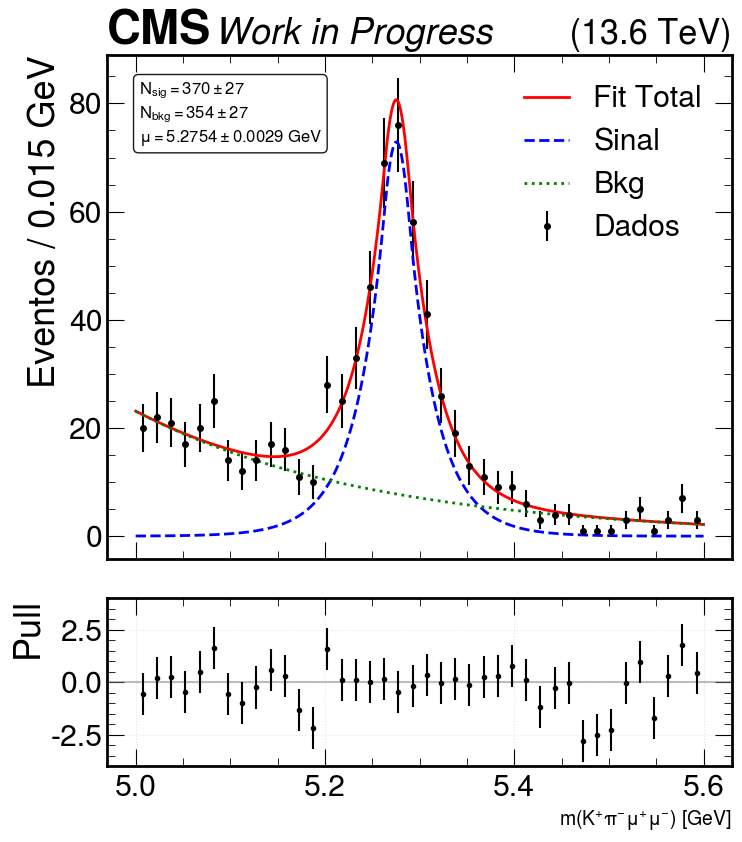

In [15]:
# 1. CALCULE OS ERROS ANTES DO PLOT
if result.valid:
    print("Fit convergiu! Calculando erros (Hesse)...")
    try:
        result.hesse() # <--- ESSA LINHA É OBRIGATÓRIA PARA TER O ['hesse']
    except Exception as e:
        print(f"Erro no Hesse: {e}")

# 2. CÓDIGO DO PLOT
fig, (ax_main, ax_res) = plt.subplots(2, 1, figsize=(8, 9), 
                           gridspec_kw={'height_ratios': [3, 1]},
                           sharex=True)

# Dados
bins_fit = 40
data_array = data_array if isinstance(data_array, np.ndarray) else data_array.to_numpy()
if len(data_array.shape) > 1: data_array = data_array.flatten()

counts, edges = np.histogram(data_array, bins=bins_fit, range=(mass_min, mass_max))
centers = 0.5 * (edges[:-1] + edges[1:])
width = edges[1] - edges[0]
yerr = np.sqrt(counts)
yerr[yerr == 0] = 1 

# Plot Principal
ax_main.errorbar(centers, counts, yerr=yerr, fmt='o', color='black', markersize=4, label='Dados')

# Fit Curves
x_fit = np.linspace(mass_min, mass_max, 500)
scale = width
pdf_total = total_pdf.pdf(x_fit).numpy() * (nsig.value() + nbkg.value()) * scale
pdf_sig = signal_pdf.pdf(x_fit).numpy() * nsig.value() * scale
pdf_bkg = bkg_pdf.pdf(x_fit).numpy() * nbkg.value() * scale

ax_main.plot(x_fit, pdf_total, 'r-', lw=2, label='Fit Total')
ax_main.plot(x_fit, pdf_sig, 'b--', lw=2, label='Sinal')
ax_main.plot(x_fit, pdf_bkg, 'g:', lw=2, label='Bkg')

# Texto dos Resultados (Com proteção contra erro se o hesse falhar)
try:
    n_s_err = result.params[nsig]['hesse']['error']
    n_b_err = result.params[nbkg]['hesse']['error']
    mu_err  = result.params[mu]['hesse']['error']
except:
    n_s_err = n_b_err = mu_err = 0

fit_text = (
    rf"$N_{{sig}} = {nsig.value():.0f} \pm {n_s_err:.0f}$" + "\n" +
    rf"$N_{{bkg}} = {nbkg.value():.0f} \pm {n_b_err:.0f}$" + "\n" +
    rf"$\mu = {mu.value():.4f} \pm {mu_err:.4f}$ GeV"
)

ax_main.text(0.05, 0.95, fit_text, transform=ax_main.transAxes, fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Resíduos
expected = total_pdf.pdf(centers).numpy() * (nsig.value() + nbkg.value()) * width
resid = (counts - expected) / yerr

ax_res.axhline(0, color='gray', alpha=0.5)
ax_res.errorbar(centers, resid, yerr=1, fmt='o', color='black', markersize=3)
ax_res.set_ylabel("Pull")
ax_res.set_ylim(-4, 4)
ax_res.grid(True, alpha=0.3)
ax_res.set_xlabel(r"$m(K^{+}\pi^{-}\mu^{+}\mu^{-})$ [GeV]", fontsize=14)

# Legendas e Estilo
ax_main.set_ylabel(f"Eventos / {width:.3f} GeV")
ax_main.legend(loc='upper right')
hep.cms.label("Work in Progress", data=True, com=13.6, ax=ax_main)

plt.tight_layout()
plt.show()

In [16]:
import zfit
import numpy as np

# --- 1. DEFINIÇÃO DOS BINS DE Q^2 ---
q2_bins = {
    0: (1.1, 2.0, "Bin 0"),
    1: (2.0, 4.3, "Bin 1"),
    2: (4.3, 6.0, "Bin 2"),
    3: (6.0, 8.68, "Bin 3"),
    4: (8.68, 10.09, "J/psi region"),
    5: (10.09, 12.86, "Bin 5"),
    6: (12.86, 14.18, "psi(2S) region"),
    7: (14.18, 16.0, "Bin 7"),
    8: (16.0, 19.0, "Bin 8")
}

# Configurações gerais
coluna_massa = 'BToTrkTrkMuMu_fit_mass_Kpi'
coluna_mll = 'BToTrkTrkMuMu_mll_fullfit' # Corrigido: representa q (massa), não q^2
mass_min = 5.0
mass_max = 5.6
obs = zfit.Space(coluna_massa, limits=(mass_min, mass_max))

# Dicionário para guardar os resultados de cada fit
fit_results = {}

# --- 2. LOOP SOBRE OS BINS ---
for bin_idx, (q2_min, q2_max, bin_name) in q2_bins.items():
    print(f"\n{'='*50}")
    print(f"Iniciando fit para o Bin {bin_idx} ({bin_name}): q² entre [{q2_min}, {q2_max}]")
    print(f"{'='*50}")
    
    # --- A. PREPARAÇÃO DOS DADOS (CORRIGIDA) ---
    # Elevamos a coluna mll ao quadrado na máscara para comparar com q2_min e q2_max
    mask_bin = ((df_bdt_cut[coluna_mll] ** 2) >= q2_min) & ((df_bdt_cut[coluna_mll] ** 2) < q2_max)
    df_bin_cut = df_bdt_cut[mask_bin]
    
    mask_mass = (df_bin_cut[coluna_massa] >= mass_min) & (df_bin_cut[coluna_massa] <= mass_max)
    df_final = df_bin_cut[mask_mass]
    
    data_array = df_final[coluna_massa].to_numpy()
    n_total = len(data_array)
    
    print(f"Eventos para o fit no Bin {bin_idx}: {n_total}")
    
    if n_total < 50: 
        print(f"Aviso: Poucos eventos ({n_total}). Pulando o bin {bin_idx}...")
        continue

    # --- B. CONFIGURAÇÃO DO ZFIT ---
    mu = zfit.Parameter(f"mu_{bin_idx}", 5.279, mass_min, mass_max)
    sigma = zfit.Parameter(f"sigma_{bin_idx}", 0.025, 0.005, 0.1)
    
    alphal = zfit.Parameter(f"alphal_{bin_idx}", 1.5, 0.1, 10.0)
    nl = zfit.Parameter(f"nl_{bin_idx}", 2.0, 0.1, 50.0)
    
    alphar = zfit.Parameter(f"alphar_{bin_idx}", 1.5, 0.1, 10.0)
    nr = zfit.Parameter(f"nr_{bin_idx}", 2.0, 0.1, 50.0)
    
    tau = zfit.Parameter(f"tau_{bin_idx}", -2.0, -10.0, 0.0)
    
    nsig = zfit.Parameter(f"nsig_{bin_idx}", int(n_total * 0.4), 0, n_total * 2)
    nbkg = zfit.Parameter(f"nbkg_{bin_idx}", int(n_total * 0.6), 0, n_total * 2)

    signal_pdf = zfit.pdf.DoubleCB(mu=mu, sigma=sigma, 
                                   alphal=alphal, nl=nl, 
                                   alphar=alphar, nr=nr, 
                                   obs=obs, extended=nsig)
    
    bkg_pdf = zfit.pdf.Exponential(lambda_=tau, obs=obs, extended=nbkg)
    total_pdf = zfit.pdf.SumPDF([signal_pdf, bkg_pdf])

    # --- C. CRIAÇÃO DO DATA E FIT ---
    data_z = zfit.Data.from_numpy(obs=obs, array=data_array)
    loss = zfit.loss.ExtendedUnbinnedNLL(model=total_pdf, data=data_z)
    
    minimizer = zfit.minimize.Minuit()
    result = minimizer.minimize(loss)
    
    fit_results[bin_idx] = result
    
    print(f"Status da convergência: {result.converged}")
    print(result)

# --- 3. RESUMO FINAL ---
print("\n" + "="*50)
print("RESUMO DOS FITS (Convergência)")
print("="*50)
for b_idx, res in fit_results.items():
    print(f"Bin {b_idx}: Convergiu? {'Sim' if res.converged else 'Não'} | Eventos de Sinal: {res.params[f'nsig_{b_idx}']['value']:.1f}")


Iniciando fit para o Bin 0 (Bin 0): q² entre [1.1, 2.0]
Eventos para o fit no Bin 0: 236
Status da convergência: True
FitResult of
<ExtendedUnbinnedNLL model=[<zfit.<class 'zfit.models.functor.SumPDF'>  params=[Composed_autoparam_4, Composed_autoparam_5]] data=[<zfit.Data: Data obs=('BToTrkTrkMuMu_fit_mass_Kpi',) shape=(236, 1)>] constraints=[]> 
with
<Minuit Minuit, tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  False  │    True     │       True       │ 0.00014 │          -209.64 |  10037.96 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name        value  (rounded)    at limit
--------  ------------------  ----------
nsig_0               122.857       False
nbkg_0               113.145       False
mu_0       